In [1]:
import xarray as xr
from sm_attribution.io.registry import default_registry
from sm_attribution.analysis.ssi import save_ssi

reg = default_registry()


In [ ]:
# Example: open a model from the registry
h08_path = reg.get_model_processed("h08", "obsclim_histsoc")  # you already produced 1m files
ds = xr.open_dataset(h08_path)

out_nc = save_ssi(
    ds["soilmoist_1m"],
    key="h08_obsclim_histsoc",
    is_model=True,
    reg=reg,
    scale=3,
    ref_start="2003-01",
    ref_end="2019-12",
)
print("Wrote:", out_nc)

Wrote: /Users/thchilly/projects/sm_attribution/data/ssi_models/standalone/ref_2003_2019/h08_obsclim_histsoc_ssi-standalone_s3_ref200301-201912.nc


Saved figure to: /Users/thchilly/projects/sm_attribution/figures/corr_multifig_obsclim_vs_counterclim.png


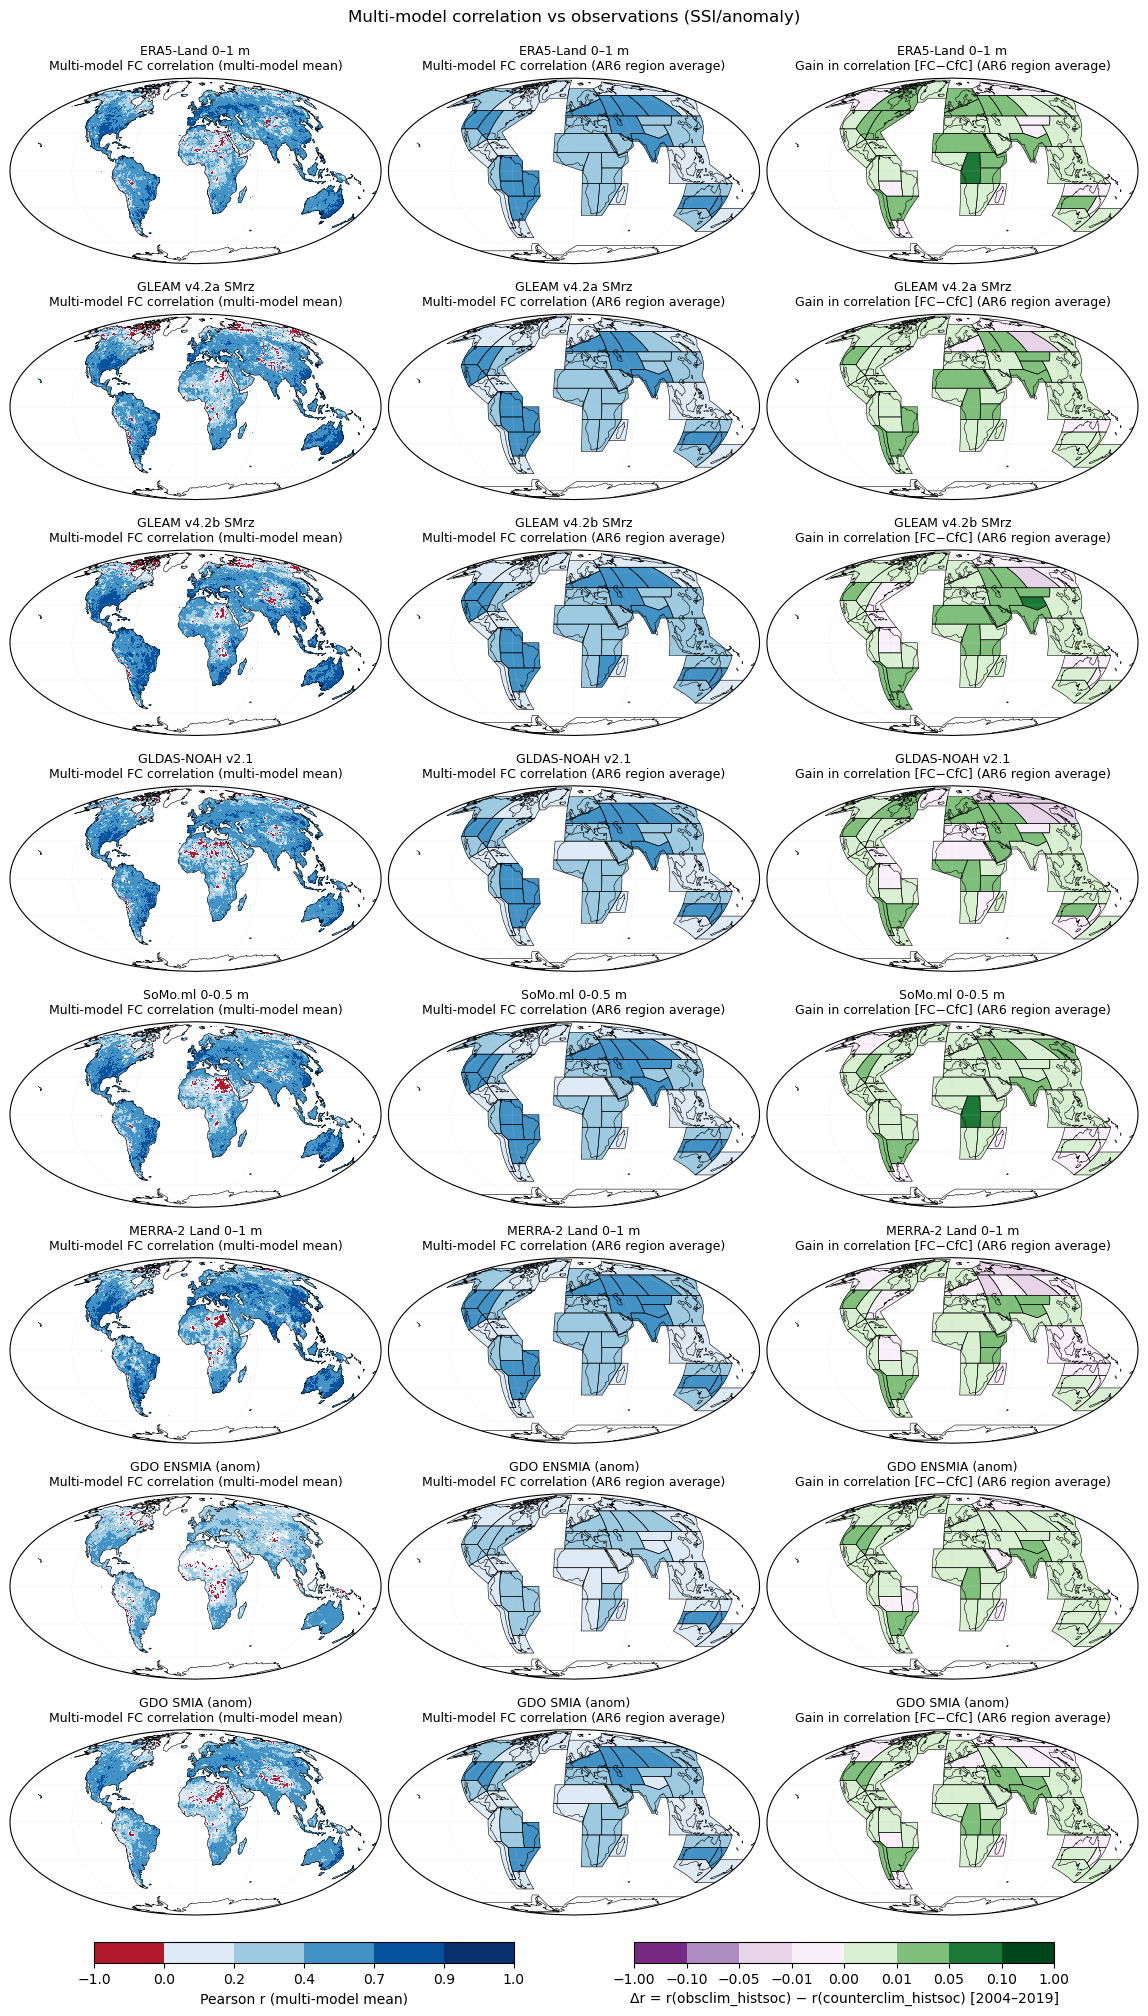

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path

from sm_attribution.viz.corr_multifig import plot_corr_multifig, DEFAULT_OBS_ROWS

# Make the figure
fig = plot_corr_multifig(
    obs_rows=DEFAULT_OBS_ROWS,
    scenario_base="obsclim_histsoc",
    scenario_counter="counterclim_histsoc",
    mode="standalone",
    corr_start="2004-01",
    corr_end="2019-12",
)

fig.suptitle("Multi-model correlation vs observations (SSI/anomaly)", y=0.99)

# ------------------------------------------------------------------
# Save to PROJECT_ROOT/figures at 300 dpi
# ------------------------------------------------------------------
# If the notebook is in PROJECT_ROOT/notebooks, go one level up:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
fig_dir = project_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

out_path = fig_dir / "corr_multifig_obsclim_vs_counterclim.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {out_path}")

# Finally show it in the notebook
plt.show()